Contents produce no significant results — notebook can be ignored. This computes a slanted MEEM configuration, a Capytaine one, and tries formulas using the potentials from the MEEM version to try and convert the hydro coefficients to match.

Approach: Using the the potentials at the two corners of a slant to approximate d_phi/d_z, and/or try some trig modifications.

Problem: The values for hydrocoefficients don't get closer to the desired value.

In [1]:
import sys
from pathlib import Path

HERE = Path.cwd().resolve()
dir_path_str = str((HERE / ".." / "..").resolve())
if dir_path_str not in sys.path:
  sys.path.insert(0, dir_path_str)
from multi_condensed import Problem
from capytaine_generator import CapytaineSlantSolver

import numpy as np
from math import pi


In [33]:
# constants block
h = 50.0
d = np.array([29.0, 7.0, 5.5, 4.0])
a = np.array([3.0, 5.0, 7.5, 10.0])
heaving = [0, 1, 1, 1] # 0/false if not heaving, 1/true if yes heaving
slant = [0, 1, 1, 1] # 0/false if not slanted, 1/true if yes slanted
NMK = [100, 100, 100, 100, 100]
omega = 0.4
rho = 1023

cpt_a = [3, 5, 10]
cpt_d_in, cpt_d_out = [29, 29, 7], [29, 7, 4]
cpt_heaving = [0, 1, 1]


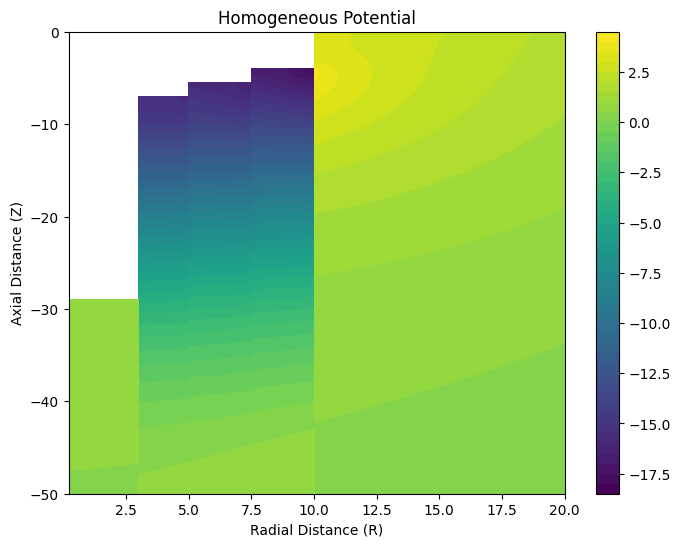

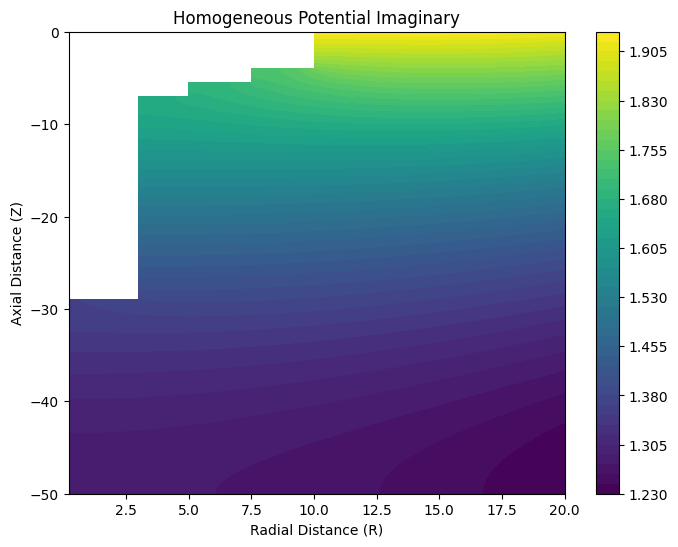

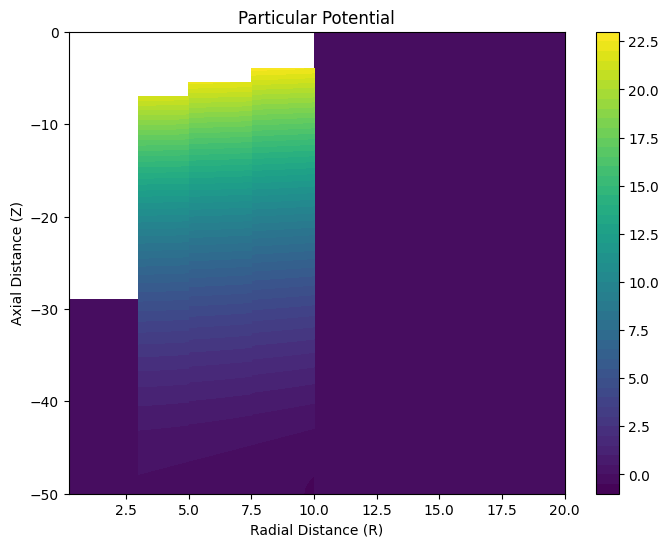

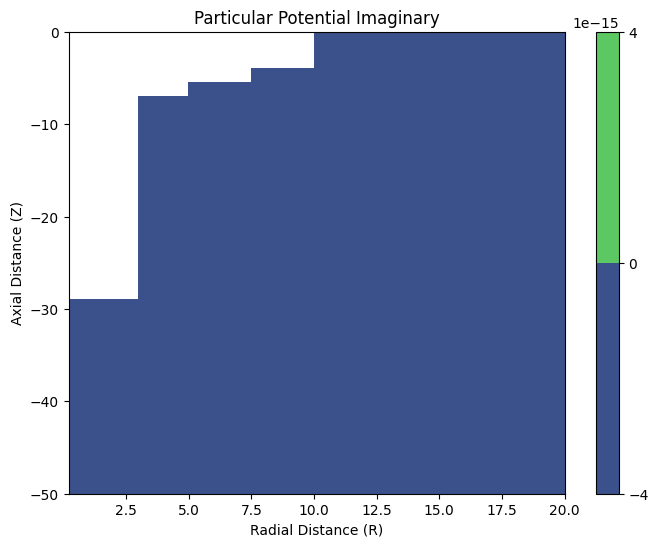

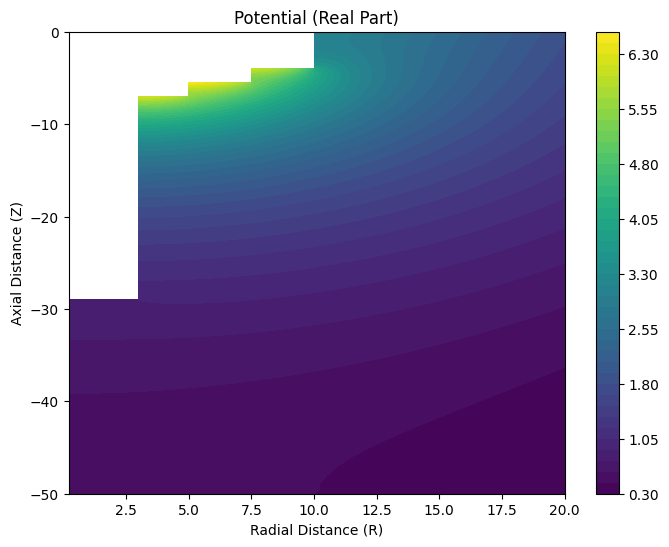

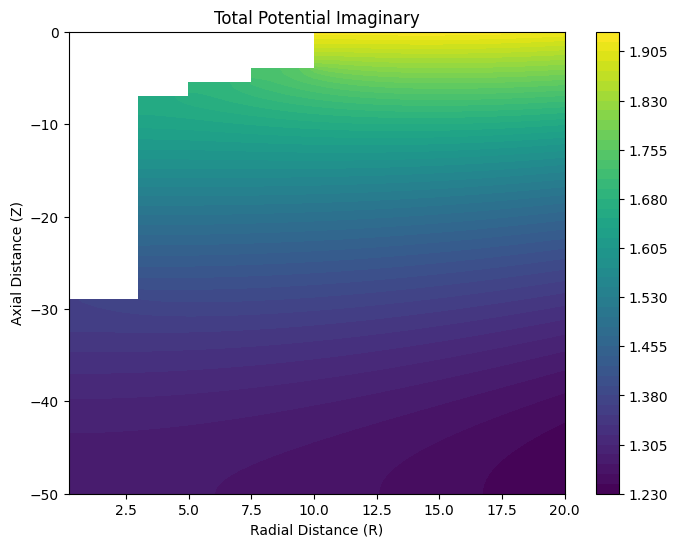

Added Mass: 1688069.1031746834
Radiation Damping: 200450.9955340387


In [34]:
prob = Problem(h, d, a, heaving, NMK, 1, rho)
prob.change_m0(prob.wavenumber(omega))
a_matrix = prob.a_matrix()
b_vector = prob.b_vector()
x = prob.get_unknown_coeffs(a_matrix, b_vector)
Cs = prob.reformat_coeffs(x)

am, dp = prob.hydro_coeffs(x, "capytaine")
boundary_count = prob.boundary_count
phi, phiH, phiP = prob.generate_potential_plot_array(Cs, res = 50)
R, Z = prob.make_R_Z(True, 50)
prob.plot_potentials(Cs, res = 100)

print("Added Mass:", am)
print("Radiation Damping:", dp)

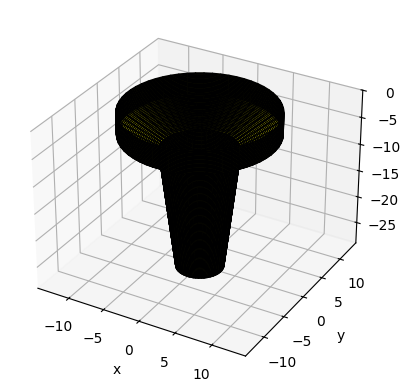

Panel Count:  7660
{'Heave': 1337921.9201053437}
{'Heave': 194781.59366867368}
Solve Time (Radiation):  138.02364907599986
Solve Time (Diffraction):  0.10604493800201453
Excitation Phase:  -0.03672099097465945


In [21]:
css = CapytaineSlantSolver(True, True, True, True, True)
_ = css.construct_and_solve(cpt_a, cpt_d_in, cpt_d_out, cpt_heaving,
                            [30, 50, 60], 150, h, omega, rho)

In [37]:
# Ways to alter computation of the slanted regions
cos_theta = np.zeros(len(NMK)-1, dtype=complex)
sin_theta = np.zeros(len(NMK)-1, dtype=complex)
delta_phi = np.zeros(len(NMK)-1, dtype=complex)
vel_z_1 = heaving.copy() # vertical velocity equal to heaving if not slant
vel_z_2 = heaving.copy()

r_coords = R[0,:]
z_coords = Z[:,0]
a_eps = 1e-4 # The "sharp" corner values, seen in multi_condensed

for i in range(boundary_count):
    if slant[i]:
        r_index = np.where(r_coords == a[i-1]*(1+a_eps))
        z_index = np.where(z_coords == -d[i-1]*(1+a_eps))
        phi_bttm_corner = phi[z_index, r_index][0,0]

        r_index = np.where(r_coords == a[i]*(1-a_eps))
        z_index = np.where(z_coords == -d[i]*(1+a_eps))
        phi_top_corner = phi[z_index, r_index][0,0]

        delta_phi[i] = phi_top_corner - phi_bttm_corner
        cos_theta[i] = (d[i-1]-d[i])/np.sqrt((d[i-1]-d[i])**2+(a[i]-a[i-1])**2)
        sin_theta[i] = (a[i]-a[i-1])/np.sqrt((d[i-1]-d[i])**2+(a[i]-a[i-1])**2)

        vel_z_1[i] = delta_phi[i] / (d[i-1]-d[i])
        vel_z_2[i] = delta_phi[i] * np.sqrt((d[i-1]-d[i])**2+(a[i]-a[i-1])**2) * cos_theta[i]

def convert_to_full(vals_by_region):
    output = np.zeros((prob.size - NMK[-1]), dtype=complex)
    output[:NMK[0]] = np.full_like(output[:NMK[0]], vals_by_region[0])
    col = NMK[0]
    for i in range(1, boundary_count):
        output[col:(col + 2 * NMK[i])] = np.full_like(output[col:(col + 2 * NMK[i])], vals_by_region[i])
        col += 2 * NMK[i]
    return output


In [ ]:
# Default components of the hydro coefficient computation
hydro_h_facts = np.zeros((prob.size - NMK[-1]), dtype=complex)

col = 0
for n in range(NMK[0]):
    hydro_h_facts[n] = heaving[0] * prob.int_R_1n(0, n) * prob.z_n_d(n)
col += NMK[0]
for i in range(1, boundary_count):
    M = NMK[i]
    for m in range(M):
        hydro_h_facts[col + m] = heaving[i] * prob.int_R_1n(i, m) * prob.z_n_d(m)
        hydro_h_facts[col + M + m] = heaving[i] * prob.int_R_2n(i, m) * prob.z_n_d(m)
    col += 2 * M

hydro_p_terms = np.zeros(boundary_count, dtype=complex)
for i in range(boundary_count):
    hydro_p_terms[i] = heaving[i] * prob.int_phi_p_i(i)

# Applying multipliers to each term
def modified_hydros(slant_mod_regionwise, slant_mod_arraywise, title):
    hydro_coef =2*pi*(np.dot(np.multiply(hydro_h_facts, slant_mod_arraywise), x[:-NMK[-1]]) + sum(np.multiply(hydro_p_terms, slant_mod_regionwise)))
    hydro_coef_cpt_real = hydro_coef.real * rho
    hydro_coef_cpt_imag = hydro_coef.imag * omega * rho

    print(title)
    print("Added Mass:", hydro_coef_cpt_real) # Capytaine convention
    print("Radiation Damping:", hydro_coef_cpt_imag)

modified_hydros(vel_z_1, convert_to_full(vel_z_1), "> Simple vertical velocity modification")
modified_hydros(vel_z_2, convert_to_full(vel_z_2), "> Projected vertical velocity modification")
modified_hydros(cos_theta, convert_to_full(cos_theta), "> Cosine")
modified_hydros(sin_theta, convert_to_full(sin_theta), "> Sine")


> Simple vertical velocity modification
Added Mass: -537070.3690932204
Radiation Damping: -46129.6216067221
> Projected vertical velocity modification
Added Mass: 29645584.36271994
Radiation Damping: 4190118.116804958
> Cosine
Added Mass: 1016061.720263082
Radiation Damping: 119602.06458009822
> Sine
Added Mass: 1212420.5789962306
Radiation Damping: 145644.08672580286
